# Import Necessary Libralies

In [40]:
# Math thingy
import numpy as np

# Data Manipulation
import pandas as pd

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# K-mean Algorithm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Read the data file

In [ ]:
def read_file(filepath):
    """reads the data file and shows as a dataframe."""
    df = pd.read_csv(filepath)
    return df

In [18]:
iris = 'iris.data'
df = read_file(iris)
df.sample(8)

,5.1,3.5,1.4,0.2,Iris-setosa
44,4.8,3.0,1.4,0.3,Iris-setosa
52,5.5,2.3,4.0,1.3,Iris-versicolor
144,6.7,3.0,5.2,2.3,Iris-virginica
5,4.6,3.4,1.4,0.3,Iris-setosa
0,4.9,3.0,1.4,0.2,Iris-setosa
81,5.8,2.7,3.9,1.2,Iris-versicolor
70,6.1,2.8,4.0,1.3,Iris-versicolor
79,5.5,2.4,3.8,1.1,Iris-versicolor


# Get the overview of the dataset

In [3]:
df.columns

Index([0, 1, 2, 3, 4], dtype='int64')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
 4   4       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [5]:
df.shape

(150, 5)

In [6]:
df.isnull().sum().sum()

0

In [7]:
df.duplicated().sum()

3

# Data Cleaning

In [35]:
def preprocessing(filepath):
    """cleans the dataset."""

    mapper = {
        0: "sepal_length",
        1: "sepal_width",
        2: "petal_length",
        3: "petal_width",
        4: "species"
    }

    # Read the data file and ADD header=None
    df = pd.read_csv(filepath, header=None)
    
    # drop duplicated rows 
    df = df.drop_duplicates()

    # Rename the columns
    df = df.rename(columns=mapper)

    return df

In [36]:
df_iris = preprocessing(iris)
df_iris.sample(5)

,sepal_length,sepal_width,petal_length,petal_width,species
18,5.7,3.8,1.7,0.3,Iris-setosa
97,6.2,2.9,4.3,1.3,Iris-versicolor
99,5.7,2.8,4.1,1.3,Iris-versicolor
31,5.4,3.4,1.5,0.4,Iris-setosa
10,5.4,3.7,1.5,0.2,Iris-setosa


# K-means Algoritmh

## Data Preparation 
- Standardize the data

In [41]:
# 1. Select only the numerical features for clustering
X = df_iris[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]

# 2. Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Identify Optimal Numbers of Cluster
- Using the elbow method

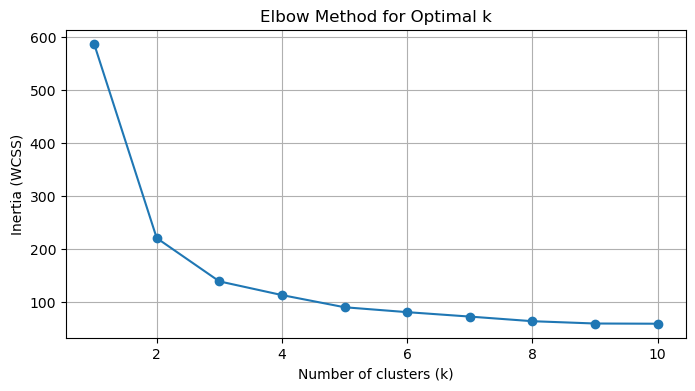

In [42]:
def optimise_k_means(data, max_k):
    """Identifies the optimal numbers of cluster."""
    
    # Corrected variable name: 'ks' instead of 'mean' for clarity
    ks = []
    inertias = []

    # Iterate from k=1 up to (but not including) max_k
    for k in range(1, max_k):
        # 1. K-means model creation and fitting
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
        kmeans.fit(data)

        # 2. Append results (k, and the inertia)
        ks.append(k)
        inertias.append(kmeans.inertia_)
        
    # Generate the elbow plot
    fig = plt.subplots(figsize=(8, 4))
    plt.plot(ks, inertias, 'o-')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('Inertia (WCSS)')
    plt.title('Elbow Method for Optimal k')
    plt.grid(True)
    plt.show()


# We'll use max_k=11 to test k=1 through k=10
optimise_k_means(X_scaled, max_k=11)